
# Ejemplo bayesiano: actualización de la certidumbre ante exámenes positivos

Este notebook ilustra cómo el Teorema de Bayes permite actualizar progresivamente la probabilidad de que una mujer esté en embarazo cuando se observan resultados positivos en exámenes de laboratorio.

> **Nota importante:** este ejemplo es exclusivamente pedagógico. No debe interpretarse como una recomendación médica ni como una representación clínica exacta de pruebas reales de embarazo. En la práctica, las probabilidades dependen del tipo de prueba, el momento de aplicación, la calidad de la muestra, el contexto clínico y otros factores.

## Situación inicial

Supongamos que inicialmente no conocemos información particular de la persona, salvo una probabilidad base:

$$
P(E)=0.02
$$

donde:

- \(E\): la mujer está en embarazo.
- \(\neg E\): la mujer no está en embarazo.

Además, suponemos que cada examen tiene una confiabilidad del 95%:

$$
P(+|E)=0.95
$$

y

$$
P(-|\neg E)=0.95
$$

Por tanto, la probabilidad de un falso positivo es:

$$
P(+|\neg E)=0.05
$$

La pregunta inicial es:

> Si el primer examen da positivo, ¿cuál es la probabilidad actualizada de embarazo?



## Paso 1 — Aplicación directa del Teorema de Bayes

Queremos calcular:

$$
P(E|+)
$$

Aplicamos Bayes:

$$
P(E|+)
=
\frac{P(+|E)P(E)}
{P(+)}
$$

donde:

$$
P(+)
=
P(+|E)P(E)
+
P(+|\neg E)P(\neg E)
$$

Sustituyendo:

$$
P(E|+)
=
\frac{0.95(0.02)}
{0.95(0.02)+0.05(0.98)}
$$

Este cálculo muestra una idea importante:

> Un examen positivo no debe interpretarse aisladamente. Su significado depende también de la probabilidad inicial del evento.


In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Probabilidad inicial de embarazo
p_embarazo = 0.02

# Sensibilidad: P(resultado positivo | embarazo)
sensibilidad = 0.95

# Especificidad: P(resultado negativo | no embarazo)
especificidad = 0.95

# Falso positivo: P(resultado positivo | no embarazo)
falso_positivo = 1 - especificidad

def actualizar_bayes(prior, sensibilidad=0.95, falso_positivo=0.05):
    """
    Actualiza P(embarazo) después de observar un resultado positivo.

    prior: P(embarazo) antes del examen.
    sensibilidad: P(+ | embarazo).
    falso_positivo: P(+ | no embarazo).
    """
    numerador = sensibilidad * prior
    denominador = sensibilidad * prior + falso_positivo * (1 - prior)
    posterior = numerador / denominador
    return posterior

posterior_1 = actualizar_bayes(p_embarazo, sensibilidad, falso_positivo)

print(f'La probabilidad posterior de embarazo después del primer resultado positivo es: {posterior_1:.4f}')


La probabilidad posterior de embarazo después del primer resultado positivo es: 0.2794



El resultado anterior indica que después de un primer examen positivo, la probabilidad de embarazo aumenta de manera importante.

Sin embargo, todavía no llega a ser cercana a 1. Esto ocurre porque la probabilidad inicial era baja y porque también existe una probabilidad de falso positivo.

La inferencia bayesiana no elimina la incertidumbre de golpe.

La actualiza.



## Paso 2 — Segundo examen positivo

Ahora viene la idea central del ejemplo.

Después del primer examen positivo, nuestra creencia ya no es:

$$
P(E)=0.02
$$

Ahora la probabilidad actualizada es:

$$
P(E|+)
$$

Esa probabilidad posterior se convierte en el nuevo prior para el segundo examen.

Si el segundo examen también da positivo, aplicamos nuevamente Bayes.

```text
Prior inicial
      ↓
Primer examen positivo
      ↓
Posterior 1
      ↓
Nuevo prior
      ↓
Segundo examen positivo
      ↓
Posterior 2
```

Este proceso puede repetirse tantas veces como nueva evidencia independiente se observe.


In [5]:

prior = p_embarazo

resultados = []

for examen in range(1, 6):
    posterior = actualizar_bayes(prior, sensibilidad, falso_positivo)

    resultados.append({
        "examen positivo número": examen,
        "prior antes del examen": prior,
        "posterior después del positivo": posterior
    })

    # El posterior se convierte en el prior del siguiente examen
    prior = posterior

df = pd.DataFrame(resultados)
df


,examen positivo número,prior antes del examen,posterior después del positivo
0,1,0.020000,0.279412
1,2,0.279412,0.880488
2,3,0.880488,0.992907
3,4,0.992907,0.999624
4,5,0.999624,0.999980



La tabla muestra cómo la probabilidad se actualiza paso a paso.

Cada resultado positivo incrementa la certidumbre, porque es evidencia compatible con el estado de embarazo.

Pero el incremento no es lineal.

El primer positivo produce un cambio grande.

El segundo produce otro cambio fuerte.

Después de varios positivos, la probabilidad se acerca rápidamente a 1.


In [6]:

df_formateado = df.copy()
df_formateado["prior antes del examen"] = df_formateado["prior antes del examen"].map(lambda x: f"{100*x:.4f}%")
df_formateado["posterior después del positivo"] = df_formateado["posterior después del positivo"].map(lambda x: f"{100*x:.4f}%")
df_formateado


,examen positivo número,prior antes del examen,posterior después del positivo
0,1,2.0000%,27.9412%
1,2,27.9412%,88.0488%
2,3,88.0488%,99.2907%
3,4,99.2907%,99.9624%
4,5,99.9624%,99.9980%



## Paso 3 — Visualización de la actualización

La siguiente gráfica muestra cómo crece la probabilidad posterior a medida que se acumulan resultados positivos independientes.


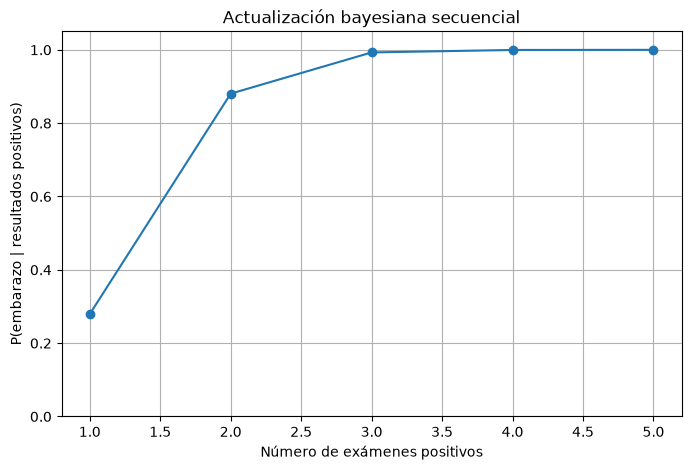

In [7]:

plt.figure(figsize=(8, 5))
plt.plot(df["examen positivo número"], df["posterior después del positivo"], marker="o")
plt.xlabel("Número de exámenes positivos")
plt.ylabel("P(embarazo | resultados positivos)")
plt.title("Actualización bayesiana secuencial")
plt.ylim(0, 1.05)
plt.grid(True)
plt.show()



## Paso 4 — Comparación con un cálculo conjunto usando 5 exámenes positivos

También podemos calcular directamente la probabilidad de embarazo después de observar cinco exámenes positivos.

Si suponemos que los exámenes son independientes condicionados al verdadero estado, entonces:

$$
P(+++++|E)
=
0.95^5
$$

y

$$
P(+++++|\neg E)
=
0.05^5
$$

Aplicando Bayes:

$$
P(E|+++++)
=
\frac{P(+++++|E)P(E)}
{P(+++++|E)P(E)+P(+++++|\neg E)P(\neg E)}
$$

Es decir:

$$
P(E|+++++)
=
\frac{0.95^5(0.02)}
{0.95^5(0.02)+0.05^5(0.98)}
$$

Este cálculo debe coincidir con la actualización secuencial después de cinco exámenes positivos.


In [8]:

n_examenes = 5

prob_5_positivos_dado_embarazo = sensibilidad ** n_examenes
prob_5_positivos_dado_no_embarazo = falso_positivo ** n_examenes

posterior_conjunto = (
    prob_5_positivos_dado_embarazo * p_embarazo
    /
    (
        prob_5_positivos_dado_embarazo * p_embarazo
        +
        prob_5_positivos_dado_no_embarazo * (1 - p_embarazo)
    )
)

posterior_secuencial = df.iloc[-1]["posterior después del positivo"]

posterior_conjunto, posterior_secuencial


(0.9999802111990075, np.float64(0.9999802111990075))


Como se observa, ambos valores son iguales salvo posibles diferencias numéricas de redondeo.

Esto ocurre porque aplicar Bayes cinco veces de manera secuencial es equivalente a aplicar Bayes una sola vez usando toda la evidencia conjunta, siempre que los exámenes sean independientes condicionados al estado real.

La diferencia está en la forma de narrarlo:

```text
Bayes secuencial:
La creencia se actualiza examen por examen.

Bayes conjunto:
Toda la evidencia se incorpora al mismo tiempo.
```


In [ ]:

comparacion = pd.DataFrame({
    "método": [
        "Bayes secuencial con 5 positivos",
        "Bayes conjunto con 5 positivos"
    ],
    "P(embarazo | evidencia)": [
        posterior_secuencial,
        posterior_conjunto
    ]
})

comparacion["P(embarazo | evidencia)"] = comparacion["P(embarazo | evidencia)"].map(lambda x: f"{100*x:.6f}%")
comparacion



## Conclusión

Este ejemplo muestra una de las ideas más importantes de la inferencia bayesiana:

> La probabilidad no se actualiza únicamente por la presencia de evidencia, sino por la compatibilidad entre esa evidencia y cada hipótesis posible.

Inicialmente, la probabilidad de embarazo era baja:

$$
P(E)=0.02
$$

Después de un primer examen positivo, la probabilidad aumenta porque el resultado positivo es mucho más compatible con embarazo que con no embarazo.

Después de varios exámenes positivos independientes, la evidencia acumulada hace que la probabilidad posterior se acerque rápidamente a 1.

En forma esquemática:

```text
Prior inicial
      ↓
Evidencia 1
      ↓
Posterior 1
      ↓
Evidencia 2
      ↓
Posterior 2
      ↓
...
      ↓
Creencia actualizada
```

La inferencia bayesiana permite, por tanto, construir certidumbre progresivamente, sin ignorar la incertidumbre inicial ni la posibilidad de error en las mediciones.
